# Clasificación de vehículos con una CNN

Este notebook carga el dataset local `Vehicles/`, entrena una red neuronal convolucional y prueba el modelo con cuatro imágenes del conjunto de validación.

## 1. Librerías y configuración reproducible

In [1]:
import os
os.environ['TF_CPP_MIN_LOG_LEVEL'] = '2'

os.environ['OPENBLAS_NUM_THREADS'] = '1'
os.environ['OMP_NUM_THREADS'] = '1'
os.environ['TF_NUM_INTRAOP_THREADS'] = '1'
os.environ['TF_NUM_INTEROP_THREADS'] = '1'

from pathlib import Path
import random
import numpy as np
import matplotlib.pyplot as plt
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers

SEED = 42
random.seed(SEED)
np.random.seed(SEED)
tf.random.set_seed(SEED)

print('TensorFlow:', tf.__version__)
print('Dispositivos disponibles:', tf.config.list_physical_devices())

TensorFlow: 2.18.1
Dispositivos disponibles: [PhysicalDevice(name='/physical_device:CPU:0', device_type='CPU')]


## 2. Carga del dataset local

In [2]:
# Ruta relativa: funciona al abrir el notebook desde la raíz del proyecto.
DATASET_DIR = Path.cwd() / 'Vehicles'
if not DATASET_DIR.is_dir():
    raise FileNotFoundError(f'No se encontró el dataset en {DATASET_DIR}')

IMAGE_SIZE = (128, 128)
BATCH_SIZE = 32
class_names = sorted(folder.name for folder in DATASET_DIR.iterdir() if folder.is_dir())
num_classes = len(class_names)

# TensorFlow no decodifica WebP. Algunos WebP del dataset tienen incluso
# extensión .jpg/.png, por eso se valida la firma binaria sin borrar archivos.
def tensorflow_compatible(path):
    with open(path, 'rb') as file:
        signature = file.read(12)
    return (signature.startswith(b'\xff\xd8') or
            signature.startswith(b'\x89PNG') or
            signature.startswith((b'GIF87a', b'GIF89a')) or
            signature.startswith(b'BM'))

rng = np.random.default_rng(SEED)
train_paths, train_labels, val_paths, val_labels, excluded = [], [], [], [], []
for class_id, class_name in enumerate(class_names):
    paths = sorted((DATASET_DIR / class_name).iterdir())
    valid_paths = [str(path) for path in paths if tensorflow_compatible(path)]
    excluded.extend(str(path) for path in paths if str(path) not in valid_paths)
    rng.shuffle(valid_paths)
    split = int(len(valid_paths) * 0.80)
    train_paths.extend(valid_paths[:split])
    train_labels.extend([class_id] * split)
    val_paths.extend(valid_paths[split:])
    val_labels.extend([class_id] * (len(valid_paths) - split))

val_order = rng.permutation(len(val_paths))
val_paths = np.asarray(val_paths)[val_order]
val_labels = np.asarray(val_labels)[val_order]

def load_image(path, label):
    content = tf.io.read_file(path)
    image = tf.io.decode_image(content, channels=3, expand_animations=False)
    image.set_shape([None, None, 3])
    image = tf.image.resize(image, IMAGE_SIZE)
    return image, tf.one_hot(label, num_classes)

train_data = (tf.data.Dataset.from_tensor_slices((train_paths, train_labels))
              .shuffle(len(train_paths), seed=SEED)
              .map(load_image, num_parallel_calls=1)
              .batch(BATCH_SIZE).prefetch(1))
validation_data = (tf.data.Dataset.from_tensor_slices((val_paths, val_labels))
                   .map(load_image, num_parallel_calls=1)
                   .batch(BATCH_SIZE).prefetch(1))

print('Clases:', class_names)
print(f'Entrenamiento: {len(train_paths)} | Validación: {len(val_paths)}')
print(f'Archivos incompatibles excluidos: {len(excluded)}')

Clases: ['Auto Rickshaws', 'Bikes', 'Cars', 'Motorcycles', 'Planes', 'Ships', 'Trains']
Entrenamiento: 4454 | Validación: 1114
Archivos incompatibles excluidos: 22


## 3. Ejemplos del dataset

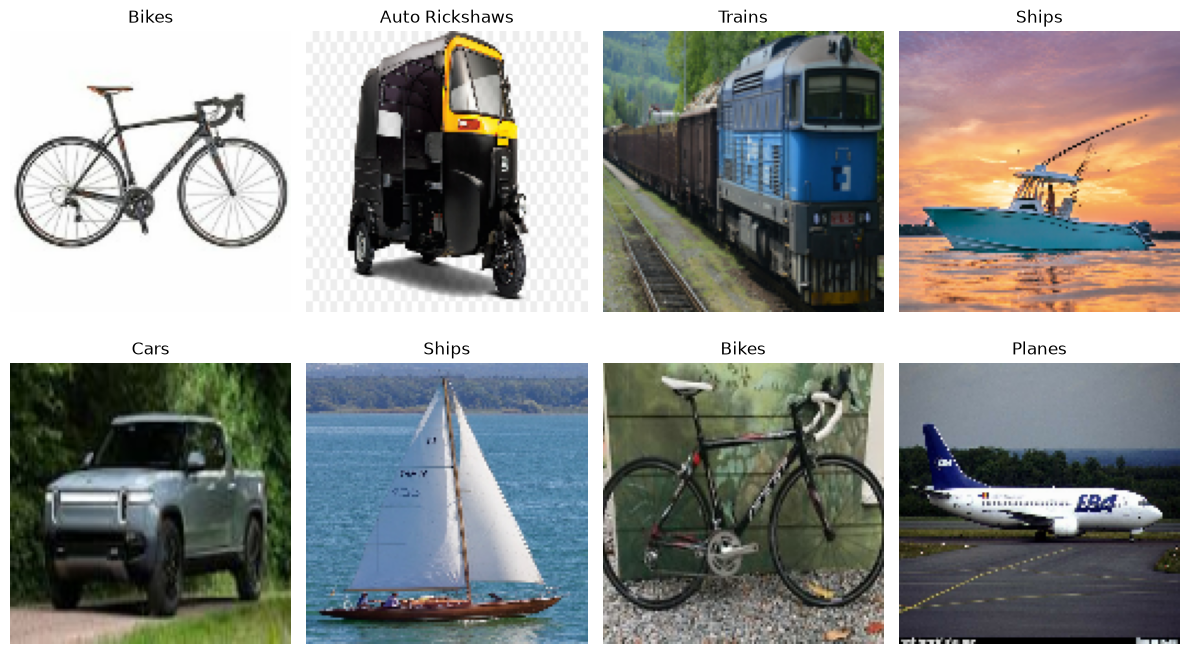

In [3]:
plt.figure(figsize=(12, 7))
images, labels = next(iter(train_data))
for i in range(8):
    ax = plt.subplot(2, 4, i + 1)
    plt.imshow(images[i].numpy().astype('uint8'))
    plt.title(class_names[np.argmax(labels[i])])
    plt.axis('off')
plt.tight_layout()
plt.show()

## 4. Preparación y modelo CNN

In [4]:
data_augmentation = keras.Sequential([
    layers.RandomFlip('horizontal', seed=SEED),
    layers.RandomRotation(0.06, seed=SEED),
    layers.RandomZoom(0.08, seed=SEED),
])

model = keras.Sequential([
    layers.Input(shape=(*IMAGE_SIZE, 3)),
    data_augmentation,
    layers.Rescaling(1./255),
    layers.Conv2D(32, 3, padding='same', activation='relu'),
    layers.MaxPooling2D(),
    layers.Conv2D(64, 3, padding='same', activation='relu'),
    layers.MaxPooling2D(),
    layers.Conv2D(128, 3, padding='same', activation='relu'),
    layers.MaxPooling2D(),
    layers.GlobalAveragePooling2D(),
    layers.Dropout(0.30),
    layers.Dense(128, activation='relu'),
    layers.Dropout(0.25),
    layers.Dense(num_classes, activation='softmax'),
])

model.compile(optimizer='adam', loss='categorical_crossentropy', metrics=['accuracy'])
model.summary()

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ sequential (Sequential)         │ (None, 128, 128, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ rescaling (Rescaling)           │ (None, 128, 128, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d (Conv2D)                 │ (None, 128, 128, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 64, 64, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 64, 64, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 32, 32, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 32, 32, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 16, 16, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d        │ (None, 128)            │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │        16,512 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 7)              │           903 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 110,663 (432.28 KB)

 Trainable params: 110,663 (432.28 KB)

 Non-trainable params: 0 (0.00 B)

## 5. Entrenamiento

In [5]:
callbacks = [
    keras.callbacks.EarlyStopping(
        monitor='val_loss', patience=2, restore_best_weights=True
    )
]

history = model.fit(
    train_data, validation_data=validation_data, epochs=3, callbacks=callbacks
)
model.save('vehicle_classifier.keras')

Epoch 1/3


/home/nelson/Documents/Uvg/Responsable_AI/REI_Tarea_AsistDev/.venv/lib/python3.12/site-packages/keras/src/trainers/epoch_iterator.py:74: UserWarning: `shuffle=True` was passed, but will be ignored since the data `x` was provided as a tf.data.Dataset. The Dataset is expected to already be shuffled (via `.shuffle(buffer_size)`).
  self.data_adapter = data_adapters.get_data_adapter(


  1/140 ━━━━━━━━━━━━━━━━━━━━ 8:21 4s/step - accuracy: 0.1875 - loss: 1.9408

  2/140 ━━━━━━━━━━━━━━━━━━━━ 2:06 919ms/step - accuracy: 0.1562 - loss: 1.9451

  3/140 ━━━━━━━━━━━━━━━━━━━━ 2:05 917ms/step - accuracy: 0.1562 - loss: 1.9477

...

137/140 ━━━━━━━━━━━━━━━━━━━━ 3s 1s/step - accuracy: 0.4345 - loss: 1.4551

138/140 ━━━━━━━━━━━━━━━━━━━━ 2s 1s/step - accuracy: 0.4343 - loss: 1.4542

139/140 ━━━━━━━━━━━━━━━━━━━━ 1s 1s/step - accuracy: 0.4348 - loss: 1.4543

140/140 ━━━━━━━━━━━━━━━━━━━━ 0s 1s/step - accuracy: 0.4349 - loss: 1.4553

140/140 ━━━━━━━━━━━━━━━━━━━━ 177s 1s/step - accuracy: 0.4349 - loss: 1.4553 - val_accuracy: 0.4210 - val_loss: 1.4569


## 6. Curvas y evaluación

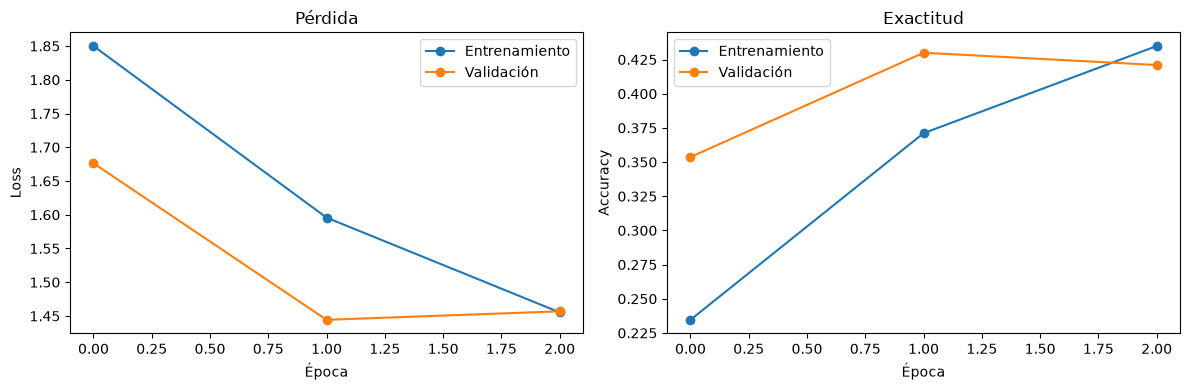

Pérdida de validación: 1.4443
Exactitud de validación: 43.00%


In [6]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
axes[0].plot(history.history['loss'], marker='o', label='Entrenamiento')
axes[0].plot(history.history['val_loss'], marker='o', label='Validación')
axes[0].set(title='Pérdida', xlabel='Época', ylabel='Loss')
axes[0].legend()

axes[1].plot(history.history['accuracy'], marker='o', label='Entrenamiento')
axes[1].plot(history.history['val_accuracy'], marker='o', label='Validación')
axes[1].set(title='Exactitud', xlabel='Época', ylabel='Accuracy')
axes[1].legend()
plt.tight_layout()
plt.show()

val_loss, val_accuracy = model.evaluate(validation_data, verbose=0)
print(f'Pérdida de validación: {val_loss:.4f}')
print(f'Exactitud de validación: {val_accuracy:.2%}')

## 7. Prueba del modelo con 4 imágenes distintas

Las imágenes se toman del conjunto de validación y no se usan para actualizar los pesos durante el entrenamiento. El color del título indica si la predicción fue correcta (verde) o incorrecta (rojo).

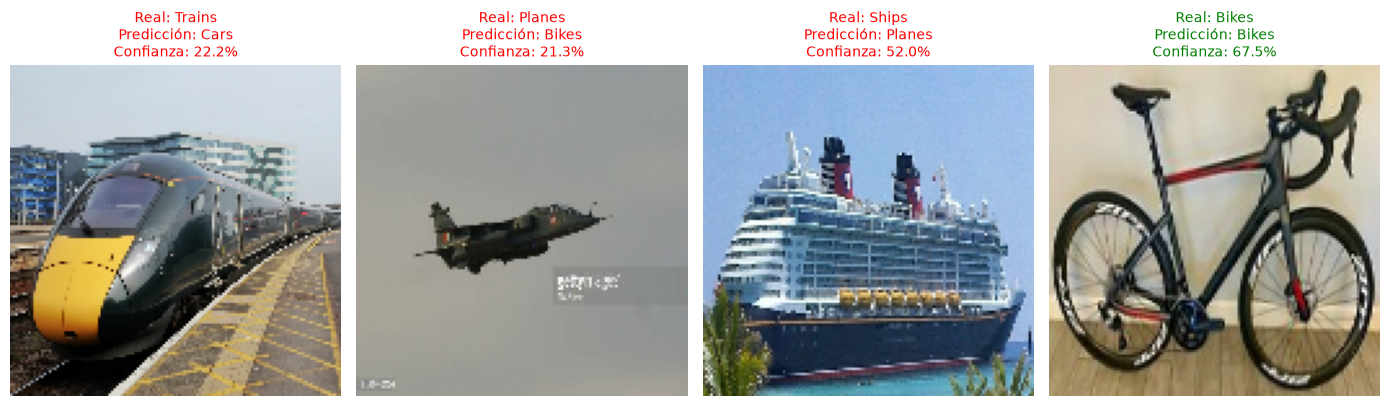

Prueba 1: real=Trains; predicción=Cars; confianza=22.20%
Prueba 2: real=Planes; predicción=Bikes; confianza=21.34%
Prueba 3: real=Ships; predicción=Planes; confianza=52.03%
Prueba 4: real=Bikes; predicción=Bikes; confianza=67.48%


In [7]:
test_images, test_labels = next(iter(validation_data))
test_images = test_images[:4]
test_labels = test_labels[:4]
probabilities = model.predict(test_images, verbose=0)
predicted_ids = np.argmax(probabilities, axis=1)
true_ids = np.argmax(test_labels.numpy(), axis=1)

plt.figure(figsize=(14, 4))
for i in range(4):
    predicted = class_names[predicted_ids[i]]
    actual = class_names[true_ids[i]]
    confidence = probabilities[i, predicted_ids[i]]
    color = 'green' if predicted_ids[i] == true_ids[i] else 'red'
    ax = plt.subplot(1, 4, i + 1)
    plt.imshow(test_images[i].numpy().astype('uint8'))
    plt.title(
        f'Real: {actual}\nPredicción: {predicted}\nConfianza: {confidence:.1%}',
        color=color, fontsize=10
    )
    plt.axis('off')
plt.tight_layout()
plt.show()

for i in range(4):
    print(
        f'Prueba {i + 1}: real={class_names[true_ids[i]]}; '
        f'predicción={class_names[predicted_ids[i]]}; '
        f'confianza={probabilities[i, predicted_ids[i]]:.2%}'
    )